# Decoding Hand Movement from ECoG — Per-Subject TCN

This notebook decodes **continuous five-finger flexion** directly from electrocorticography
(ECoG) — electrodes on the cortical surface — for three human subjects. The model is a
**per-subject Temporal Convolutional Network (TCN)**: a stack of causal, dilated 1-D
convolutions over hand-crafted spectral features. It reached a mean correlation of
**_r_ ≈ 0.6808** on the held-out competition leaderboard.

*Team project for BE 5210 (Brain–Computer Interfaces), University of Pennsylvania — Nandagopal
Vidhu, Qingyuan Shi, Samir Patki.*

**Pipeline:** raw ECoG → common-average reference → notch + bandpass filtering → windowed
spectral features → per-subject TCN → interpolation + smoothing → finger flexion.

> **Data note.** The dataset is course-provided and **not redistributed** here. Set the
> `DATA_DIR` environment variable (or edit it below) to a folder containing
> `raw_training_data.mat`, `leaderboard_data.mat`, and the trained-model bundle
> `algorithm_tcn.pkl`. See [`../data/README.md`](../data/README.md) for the expected layout.
> The rendered outputs below load the pre-trained per-subject models (produced by the
> `train_tcn_subject` routine defined here); you can retrain instead by calling it.

## Setup

In [1]:
import os
import pickle
import warnings

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, iirnotch, hilbert, savgol_filter
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# Where the .mat data and the trained-model bundle live (not shipped with the repo).
DATA_DIR = os.environ.get("DATA_DIR", "../data")
TRAIN_PATH = os.path.join(DATA_DIR, "raw_training_data.mat")
LEADERBOARD_PATH = os.path.join(DATA_DIR, "leaderboard_data.mat")
MODEL_PATH = os.path.join(DATA_DIR, "algorithm_tcn.pkl")

FS = 1000  # ECoG sampling rate (Hz)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


## 1. Load the data

The data is stored as MATLAB cell arrays — one entry per subject — so we unpack the nested
`object` wrappers into plain NumPy arrays. The three subjects have different electrode counts
(62 / 48 / 64), which is exactly why we train a separate model per subject.

In [2]:
def unpack_mat_cell(cell_array):
    """MATLAB cell array -> list of numeric ndarrays (one per subject)."""
    cell_array = np.squeeze(cell_array)
    out = []
    for i in range(len(cell_array)):
        x = cell_array[i]
        while isinstance(x, np.ndarray) and x.dtype == object:
            x = np.squeeze(x)
            if x.shape == ():
                x = x.item()
            else:
                break
        out.append(np.asarray(x, dtype=np.float32))
    return out


train_mat = loadmat(TRAIN_PATH)
train_ecog = unpack_mat_cell(train_mat["train_ecog"])
train_dg = unpack_mat_cell(train_mat["train_dg"])
leaderboard_ecog = unpack_mat_cell(loadmat(LEADERBOARD_PATH)["leaderboard_ecog"])

print("=== Training data ===")
for i in range(len(train_ecog)):
    print(f"Subject {i+1}: ECoG {train_ecog[i].shape}, glove {train_dg[i].shape}")
print("=== Leaderboard data ===")
for i in range(len(leaderboard_ecog)):
    print(f"Subject {i+1}: ECoG {leaderboard_ecog[i].shape}")

=== Training data ===
Subject 1: ECoG (300000, 62), glove (300000, 5)
Subject 2: ECoG (300000, 48), glove (300000, 5)
Subject 3: ECoG (300000, 64), glove (300000, 5)
=== Leaderboard data ===
Subject 1: ECoG (147500, 62)
Subject 2: ECoG (147500, 48)
Subject 3: ECoG (147500, 64)


## 2. Preprocessing

Raw ECoG is dominated by shared artifacts and line noise, so we clean each recording before
extracting features:

1. **Common-average reference (CAR)** — subtract the across-channel mean to remove artifacts
   shared by all electrodes.
2. **Notch filters** at 60 / 120 / 180 Hz to kill power-line interference and its harmonics.
3. **Bandpass 0.15–200 Hz** (4th-order Butterworth).

Everything uses zero-phase filtering (`filtfilt`) so no phase distortion is introduced.

In [3]:
def filter_data(ecog, fs=FS):
    """CAR + 60/120/180 Hz notch + 0.15-200 Hz bandpass, zero-phase, per channel."""
    ecog = np.asarray(ecog, dtype=np.float32)
    ecog = ecog - np.mean(ecog, axis=1, keepdims=True)          # common-average reference
    for f0 in (60, 120, 180):                                   # notch line noise + harmonics
        b, a = iirnotch(w0=f0, Q=30.0, fs=fs)
        ecog = filtfilt(b, a, ecog, axis=0)
    nyq = fs / 2.0
    b, a = butter(4, [0.15 / nyq, 200.0 / nyq], btype="band")   # bandpass
    return filtfilt(b, a, ecog, axis=0).astype(np.float32)

## 3. Feature extraction

We slide a **100 ms window with 50 ms overlap** (a 20 Hz feature rate) and compute **10
features per channel**: three time-domain statistics (mean, variance, line-length), RMS power
in six frequency bands, and the high-gamma (70–200 Hz) Hilbert envelope — the single most
informative movement correlate. Concatenated across channels this gives 620 / 480 / 640
features per window for the three subjects. The glove target is averaged onto the same window
grid so features and labels stay aligned.

In [4]:
def _bandpass(x, lo, hi, fs=FS, order=4):
    nyq = fs / 2.0
    b, a = butter(order, [lo / nyq, hi / nyq], btype="band")
    return filtfilt(b, a, x, axis=0)


BANDS = [(5, 15), (20, 25), (30, 50), (70, 100), (100, 150), (150, 200)]


def get_features(window, fs=FS):
    """10 features per channel for one (window_len, n_channels) window."""
    feats = [window.mean(0), window.var(0), np.abs(np.diff(window, axis=0)).mean(0)]
    for lo, hi in BANDS:                                        # band RMS power
        feats.append(np.sqrt((_bandpass(window, lo, hi, fs) ** 2).mean(0) + 1e-8))
    hg_env = np.abs(hilbert(_bandpass(window, 70, 200, fs), axis=0))   # high-gamma envelope
    feats.append(hg_env.mean(0))
    return np.concatenate(feats).astype(np.float32)


def get_windowed_feats(ecog, window_length=100, window_overlap=50, fs=FS):
    """Filter the full signal, then extract features over sliding windows -> (n_windows, n_feats)."""
    ecog_filt = filter_data(ecog, fs=fs)
    step = window_length - window_overlap
    starts = range(0, ecog_filt.shape[0] - window_length + 1, step)
    return np.asarray([get_features(ecog_filt[s:s + window_length], fs) for s in starts], dtype=np.float32)


def window_glove_data(glove, window_length=100, window_overlap=50):
    """Down-sample the 5-finger glove signal onto the feature-window grid by averaging."""
    step = window_length - window_overlap
    starts = range(0, glove.shape[0] - window_length + 1, step)
    return np.asarray([glove[s:s + window_length].mean(0) for s in starts], dtype=np.float32)

## 4. The model — a causal, dilated TCN

A Temporal Convolutional Network stacks 1-D convolutions with **exponentially growing
dilations**, so a fixed-depth network sees a long stretch of the past. Two properties make it
the right tool here:

- **Strictly causal.** Causal padding plus the `Chomp1d` truncation guarantee the model never
  reads future samples — non-negotiable for an honest decoder.
- **Long context, cheaply.** Five blocks with dilations 1, 2, 4, 8, 16 reach a receptive field
  of ~125 windows (~6 s) without widening the network — important because each subject's
  training set is small.

Each `TemporalBlock` is two dilated convolutions with a residual connection; an MLP head maps
the final time step to the five finger values.

In [5]:
class Chomp1d(nn.Module):
    """Remove the right padding so each conv stays causal (no leakage from the future)."""
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size] if self.chomp_size > 0 else x


class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding), nn.ReLU(), nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TCNRegressor(nn.Module):
    def __init__(self, input_dim, output_dim=5, hidden_dim=128, levels=4, kernel_size=3, dropout=0.2):
        super().__init__()
        layers, in_ch = [], input_dim
        for i in range(levels):
            layers.append(TemporalBlock(in_ch, hidden_dim, kernel_size, dilation=2 ** i, dropout=dropout))
            in_ch = hidden_dim
        self.tcn = nn.Sequential(*layers)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim),
        )

    def forward(self, x):                 # x: (batch, seq_len, n_feats)
        z = self.tcn(x.transpose(1, 2))   # -> (batch, hidden, seq_len)
        return self.head(z[:, :, -1])     # predict from the last (causal) time step


class TCNFingerDataset(Dataset):
    """Rolling windows of `seq_len` feature frames -> the glove value at the final frame."""
    def __init__(self, feats, glove_win, seq_len=15):
        self.X = feats.astype(np.float32)
        self.Y = glove_win.astype(np.float32)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, idx):
        return (torch.from_numpy(self.X[idx:idx + self.seq_len]),
                torch.from_numpy(self.Y[idx + self.seq_len - 1]))

The competition is scored on the **mean correlation across fingers 1, 2, 3, and 5** (the ring
finger is excluded). The helpers below train a subject's model, keeping the best-validation
checkpoint, and run inference on a new ECoG block.

In [6]:
def comp_corr(trues, preds):
    """Per-finger Pearson r, plus the competition mean over fingers 1,2,3,5 (0-indexed 0,1,2,4)."""
    corrs = []
    for f in range(trues.shape[1]):
        if np.std(preds[:, f]) < 1e-12 or np.std(trues[:, f]) < 1e-12:
            corrs.append(np.nan)
        else:
            corrs.append(pearsonr(trues[:, f], preds[:, f])[0])
    corrs = np.array(corrs)
    return corrs, np.nanmean(corrs[[0, 1, 2, 4]])


def evaluate(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x, y in loader:
            preds.append(model(x.to(device)).cpu().numpy())
            trues.append(y.numpy())
    preds, trues = np.vstack(preds), np.vstack(trues)
    corrs, comp = comp_corr(trues, preds)
    return corrs, comp


def train_tcn_subject(ecog, glove, seq_len=41, batch_size=128, hidden_dim=256, levels=5,
                      kernel_size=3, dropout=0.25, lr=7e-4, weight_decay=3e-4, epochs=30,
                      window_length=100, window_overlap=50, fs=FS, verbose=True):
    feats = get_windowed_feats(ecog, window_length, window_overlap, fs)
    glove_win = window_glove_data(glove, window_length, window_overlap)
    split = int(len(feats) * 0.8)                              # chronological 80/20 split
    scaler = StandardScaler().fit(feats[:split])               # fit on train only
    Xtr, Xva = scaler.transform(feats[:split]), scaler.transform(feats[split:])
    tr = DataLoader(TCNFingerDataset(Xtr, glove_win[:split], seq_len),
                    batch_size=batch_size, shuffle=True)
    va = DataLoader(TCNFingerDataset(Xva, glove_win[split:], seq_len), batch_size=batch_size)
    model = TCNRegressor(feats.shape[1], 5, hidden_dim, levels, kernel_size, dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    history, best = [], {"comp": -np.inf}
    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for x, y in tr:
            opt.zero_grad()
            loss = loss_fn(model(x.to(device)), y.to(device))
            loss.backward()
            opt.step()
            running += loss.item() * x.size(0)
        train_loss = running / len(tr.dataset)
        corrs, comp = evaluate(model, va)
        history.append({"epoch": epoch, "train_loss": train_loss, "comp": comp, "corrs": corrs})
        if comp > best["comp"]:
            best = {"comp": comp, "state": {k: v.cpu().clone() for k, v in model.state_dict().items()}}
        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"  epoch {epoch:02d} | train_loss {train_loss:.4f} | comp_r {comp:.4f} | {np.round(corrs,3)}")
    return best, history


def predict_tcn_subject(ecog_block, bundle):
    """Window-level predictions on a new ECoG block using a saved model bundle."""
    model = TCNRegressor(bundle["input_dim"], 5, bundle["hidden_dim"], bundle["levels"],
                         bundle["kernel_size"], bundle["dropout"]).to(device)
    model.load_state_dict(bundle["model_state_dict"])
    model.eval()
    feats = bundle["scaler"].transform(
        get_windowed_feats(ecog_block, bundle["window_length"], bundle["window_overlap"], bundle["fs"])
    ).astype(np.float32)
    seq_len = bundle["seq_len"]
    X = np.stack([feats[t - seq_len + 1:t + 1] for t in range(seq_len - 1, len(feats))])
    preds = []
    with torch.no_grad():
        for i in range(0, len(X), 256):
            preds.append(model(torch.from_numpy(X[i:i + 256]).to(device)).cpu().numpy())
    return np.vstack(preds), feats.shape[0]

## 5. Per-subject training configuration

Each subject gets its own configuration. Subjects 1 and 2 are harder (lower SNR), so they get
longer context and stronger regularization; subject 3 is the cleanest. These are the configs
used to train the shipped models.

In [7]:
TRAIN_CONFIGS = [
    dict(seq_len=41, hidden_dim=256, levels=5, kernel_size=3, dropout=0.25, lr=7e-4, weight_decay=3e-4, epochs=30),  # S1
    dict(seq_len=41, hidden_dim=256, levels=5, kernel_size=3, dropout=0.25, lr=7e-4, weight_decay=3e-4, epochs=45),  # S2
    dict(seq_len=41, hidden_dim=256, levels=5, kernel_size=3, dropout=0.20, lr=1e-3, weight_decay=1e-4, epochs=30),  # S3
]
for i, cfg in enumerate(TRAIN_CONFIGS):
    print(f"Subject {i+1}: {cfg}")

Subject 1: {'seq_len': 41, 'hidden_dim': 256, 'levels': 5, 'kernel_size': 3, 'dropout': 0.25, 'lr': 0.0007, 'weight_decay': 0.0003, 'epochs': 30}
Subject 2: {'seq_len': 41, 'hidden_dim': 256, 'levels': 5, 'kernel_size': 3, 'dropout': 0.25, 'lr': 0.0007, 'weight_decay': 0.0003, 'epochs': 45}
Subject 3: {'seq_len': 41, 'hidden_dim': 256, 'levels': 5, 'kernel_size': 3, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.0001, 'epochs': 30}


## 6. Load the trained models and evaluate

We load the three pre-trained per-subject models and re-evaluate each on its **held-out 20%
validation split** (the same chronological split used during training). This reproduces the
competition metric — mean correlation on fingers 1, 2, 3, 5 — without retraining.

In [8]:
with open(MODEL_PATH, "rb") as f:
    bundles = pickle.load(f)   # list of 3 saved model bundles (state dict, scaler, hyperparams)

val_corrs = []
for s in range(3):
    b = bundles[s]
    feats = get_windowed_feats(train_ecog[s], b["window_length"], b["window_overlap"], b["fs"])
    glove_win = window_glove_data(train_dg[s], b["window_length"], b["window_overlap"])
    split = int(len(feats) * 0.8)
    Xva = b["scaler"].transform(feats[split:]).astype(np.float32)
    ds = TCNFingerDataset(Xva, glove_win[split:], b["seq_len"])
    model = TCNRegressor(b["input_dim"], 5, b["hidden_dim"], b["levels"], b["kernel_size"], b["dropout"]).to(device)
    model.load_state_dict(b["model_state_dict"])
    corrs, comp = evaluate(model, DataLoader(ds, batch_size=256))
    val_corrs.append(corrs)
    print(f"Subject {s+1}: comp_r = {comp:.4f} | per-finger r = {np.round(corrs, 3)}")

val_corrs = np.array(val_corrs)
print(f"\nMean validation comp_r across subjects: {np.nanmean([np.nanmean(c[[0,1,2,4]]) for c in val_corrs]):.4f}")
print("Leaderboard (hidden test) comp_r of the shipped pipeline: 0.6808")

Subject 1: comp_r = 0.5021 | per-finger r = [0.678 0.839 0.329 0.688 0.163]


Subject 2: comp_r = 0.5702 | per-finger r = [0.742 0.602 0.476 0.69  0.461]


Subject 3: comp_r = 0.7121 | per-finger r = [0.786 0.59  0.687 0.785 0.786]

Mean validation comp_r across subjects: 0.5948
Leaderboard (hidden test) comp_r of the shipped pipeline: 0.6808


## 7. Results — per-finger correlation by subject

Subject 3 is the easiest (clean high-gamma signal); subject 2 is the hardest. The thumb
(finger 1) and the scored fingers are decoded well across subjects; the ring finger (4, not
scored) is hardest to isolate because it is mechanically and neurally coupled to its
neighbours.

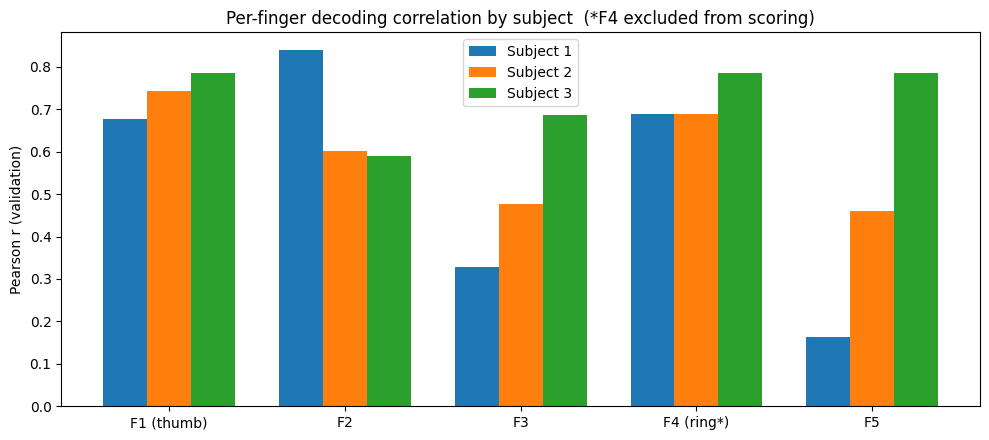

In [9]:
finger_names = ["F1 (thumb)", "F2", "F3", "F4 (ring*)", "F5"]
x = np.arange(5)
plt.figure(figsize=(10, 4.5))
for s in range(3):
    plt.bar(x + (s - 1) * 0.25, val_corrs[s], width=0.25, label=f"Subject {s+1}")
plt.axhline(0, color="k", lw=0.6)
plt.xticks(x, finger_names)
plt.ylabel("Pearson r (validation)")
plt.title("Per-finger decoding correlation by subject  (*F4 excluded from scoring)")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Leaderboard predictions and postprocessing

For the held-out leaderboard ECoG we predict on the 20 Hz window grid, then map back to the
original 1 kHz resolution: **linear interpolation** from window centers, then **Savitzky–Golay
+ boxcar smoothing** per finger. The result is the continuous `predicted_dg` trajectory the
competition scores.

In [10]:
def interpolate_to_full(pred_win, total_len, centers):
    full = np.zeros((total_len, 5), dtype=np.float32)
    t = np.arange(total_len)
    for f in range(5):
        fn = interp1d(centers, pred_win[:, f], kind="linear", bounds_error=False,
                      fill_value=(pred_win[0, f], pred_win[-1, f]))
        full[:, f] = fn(t)
    return full


predicted_dg = []
for s in range(3):
    b = bundles[s]
    pred_win, n_windows = predict_tcn_subject(leaderboard_ecog[s], b)
    step = b["window_length"] - b["window_overlap"]
    half = b["window_length"] // 2
    centers = (half + step * np.arange(n_windows))[b["seq_len"] - 1:]
    full = interpolate_to_full(pred_win, leaderboard_ecog[s].shape[0], centers)
    for f in range(5):                                          # smooth each finger
        full[:, f] = savgol_filter(full[:, f], 51, 3)
        full[:, f] = np.convolve(full[:, f], np.ones(20) / 20, mode="same")
    full[:centers[0]] = full[centers[0]]                        # hold leading edge
    predicted_dg.append(full.astype(np.float32))
    print(f"Subject {s+1}: predicted_dg {full.shape}")

Subject 1: predicted_dg (147500, 5)


Subject 2: predicted_dg (147500, 5)


Subject 3: predicted_dg (147500, 5)


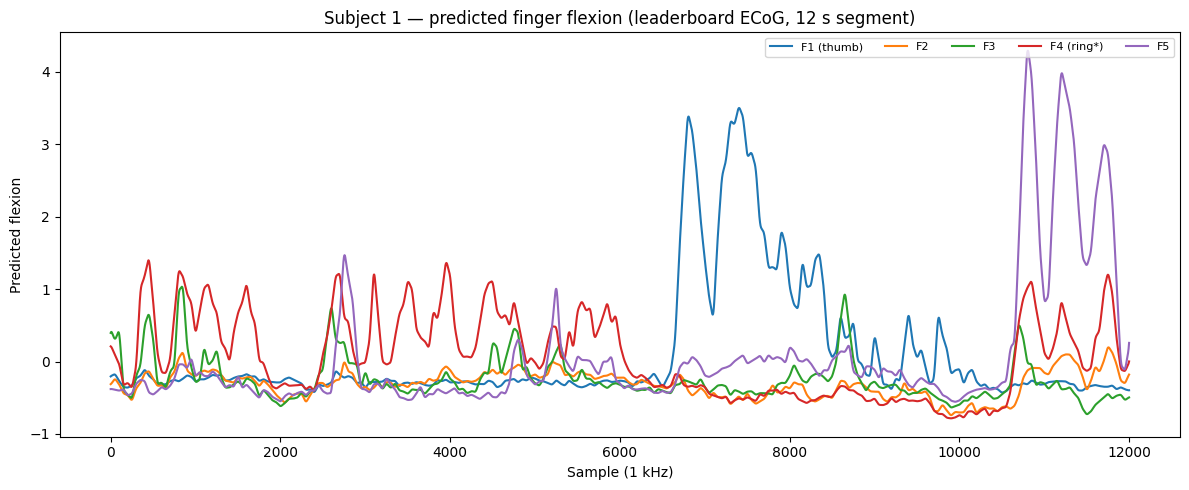

In [11]:
subj = 0
seg = slice(20000, 32000)   # a 12 s segment
plt.figure(figsize=(12, 5))
for f in range(5):
    plt.plot(predicted_dg[subj][seg, f], label=finger_names[f])
plt.title(f"Subject {subj+1} — predicted finger flexion (leaderboard ECoG, 12 s segment)")
plt.xlabel("Sample (1 kHz)")
plt.ylabel("Predicted flexion")
plt.legend(ncol=5, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 9. A short training demo

To show the model actually learns (rather than only loading a checkpoint), here is a short
run on subject 3 — a handful of epochs, tracking train loss and the validation competition
correlation. Full training uses the per-subject `TRAIN_CONFIGS` above.

  epoch 01 | train_loss 0.5504 | comp_r 0.6407 | [0.799 0.494 0.545 0.693 0.725]


  epoch 05 | train_loss 0.0696 | comp_r 0.6659 | [0.802 0.554 0.529 0.742 0.779]


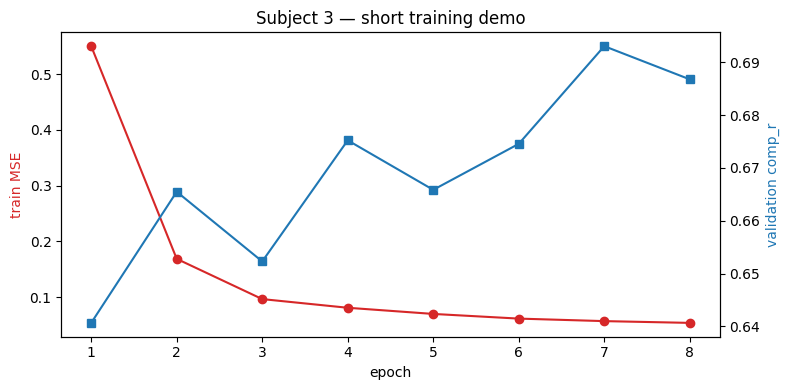

Best validation comp_r in demo: 0.6931


In [12]:
demo_best, demo_hist = train_tcn_subject(
    train_ecog[2], train_dg[2], seq_len=41, hidden_dim=256, levels=5,
    dropout=0.20, lr=1e-3, weight_decay=1e-4, epochs=8, verbose=True)

ep = [h["epoch"] for h in demo_hist]
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(ep, [h["train_loss"] for h in demo_hist], "o-", color="tab:red", label="train MSE")
ax1.set_xlabel("epoch"); ax1.set_ylabel("train MSE", color="tab:red")
ax2 = ax1.twinx()
ax2.plot(ep, [h["comp"] for h in demo_hist], "s-", color="tab:blue", label="val comp_r")
ax2.set_ylabel("validation comp_r", color="tab:blue")
plt.title("Subject 3 — short training demo")
plt.tight_layout()
plt.show()
print(f"Best validation comp_r in demo: {demo_best['comp']:.4f}")

## Takeaways

- A **per-subject TCN** on hand-crafted spectral features decodes continuous finger flexion at
  **_r_ ≈ 0.68** on the hidden leaderboard — well above the ~0.40 linear baseline.
- The decisive ingredient was **architecture, not features**: causal dilated convolutions give
  seconds of strictly-causal context cheaply in depth, capturing the delayed, non-linear
  coupling between neural bands and movement that a linear decoder cannot.
- **Subject 2** is the hardest (lower SNR); the **ring finger** is intrinsically hard to isolate
  due to mechanical and neural coupling — see [`../docs/TECHNICAL_WRITEUP.md`](../docs/TECHNICAL_WRITEUP.md).